In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

f:\app space\Anaconda\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [ ]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# df=pd.read_csv('/Users/mohammadhosein/Desktop/churn_project/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (7043, 21)


In [ ]:
duplicated_rows = df[df.duplicated()]
print(f"Number of duplicated rows: {duplicated_rows.shape[0]}")

Number of duplicated rows: 0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df = df.drop(columns=['customerID'])

# Convert TotalCharges to numeric, coercing spaces to NaN
df["MonthlyCharges"] = pd.to_numeric(df["MonthlyCharges"], errors="coerce")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Now drop the created NaN rows
df.dropna(inplace=True)

df.isnull().sum()  # should be 0 for all columns

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


<title>تحلیل متغیرهای کلیدی</title>
    <style>
        body {
            font-family: 'B Nazanin', 'Tahoma', sans-serif;
            line-height: 1.8;
            color: #333;
            max-width: 900px;
            margin: 0 auto;
            padding: 20px;
            background-color: #f9f9f9;
        }
        h1 {
            color: #2c3e50;
            border-bottom: 2px solid #3498db;
            padding-bottom: 10px;
            text-align: center;
        }
        h2 {
            color: #2980b9;
            margin-top: 25px;
        }
        .variable {
            background: white;
            border-radius: 8px;
            padding: 15px;
            margin-bottom: 20px;
            box-shadow: 0 2px 5px rgba(0,0,0,0.1);
        }
        .variable-title {
            font-weight: bold;
            color: #16a085;
            margin-bottom: 10px;
            font-size: 1.1em;
        }
        .key-findings {
            background: #e8f4fc;
            border-radius: 8px;
            padding: 15px;
            margin-top: 30px;
        }
        .key-findings-title {
            color: #2c3e50;
            font-weight: bold;
            margin-bottom: 10px;
        }
        .stat {
            margin: 5px 0;
        }
        .highlight {
            color: #e74c3c;
            font-weight: bold;
        }

    <h1>تحلیل متغیرهای کلیدی دیتاست مشتریان</h1>

    <div class="variable">
        <div class="variable-title">Senior Citizen</div>
        <div class="stat">
            میانگین این متغیر برابر <span class="highlight">0.162</span> است.
            از آنجا که این ویژگی دودویی (0 و 1) است، این مقدار نشان می‌دهد
            حدود <span class="highlight">16.2٪</span> از مشتریان سالمند هستند و
            نزدیک به <span class="highlight">83.8٪</span> در این گروه قرار نمی‌گیرند.
        </div>
    </div>

    <div class="variable">
        <div class="variable-title">Tenure</div>
        <div class="stat">
            مدت زمان همکاری مشتریان با شرکت از 0 تا 72 ماه متغیر است.
        </div>
        <div class="stat">
            میانگین مدت همکاری: <span class="highlight">32.37 ماه</span>
        </div>
        <div class="stat">
            میانه: <span class="highlight">29 ماه</span>
        </div>
        <div class="stat">
            25٪ مشتریان کمتر از <span class="highlight">9 ماه</span> سابقه دارند،
            در حالی که 25٪ دیگر بیش از <span class="highlight">55 ماه</span> با شرکت همکاری کرده‌اند.
        </div>
        <div class="stat">
            این موضوع نشان‌دهنده تنوع قابل توجه در میزان وفاداری مشتریان است.
        </div>
    </div>

    <div class="variable">
        <div class="variable-title">MonthlyCharges</div>
        <div class="stat">
            هزینه ماهانه مشتریان بین <span class="highlight">18.25 تا 118.75 دلار</span> قرار دارد.
        </div>
        <div class="stat">
            میانگین هزینه ماهانه: <span class="highlight">64.76 دلار</span>
        </div>
        <div class="stat">
            میانه: <span class="highlight">70.35 دلار</span>
        </div>
        <div class="stat">
            انحراف معیار: <span class="highlight">30.09 دلار</span>
        </div>
        <div class="stat">
            اختلاف نسبتاً زیاد بین حداقل و حداکثر مقدار نشان می‌دهد
            هزینه خدمات مشتریان دارای پراکندگی قابل توجهی است که
            احتمالاً به تفاوت در نوع خدمات و بسته‌های انتخابی مربوط می‌شود.
        </div>
    </div>

    <div class="key-findings">
        <div class="key-findings-title">یافته‌های کلیدی</div>
        <ul>
            <li>حدود <span class="highlight">16٪</span> از مشتریان سالمند هستند.</li>
            <li>میانگین سابقه همکاری مشتریان حدود <span class="highlight">32 ماه</span> است.</li>
            <li>نیمی از مشتریان کمتر از <span class="highlight">29 ماه</span> سابقه همکاری دارند.</li>
            <li>هزینه ماهانه مشتریان به طور متوسط <span class="highlight">64.76 دلار</span> است.</li>
            <li>دامنه گسترده مقادیر <span class="highlight">MonthlyCharges</span> و <span class="highlight">tenure</span> نشان می‌دهد دیتاست شامل مشتریانی با الگوهای مصرف و میزان وفاداری بسیار متنوع است؛ موضوعی که می‌تواند در پیش‌بینی Churn نقش مهمی ایفا کند.</li>
        </ul>
    </div>



# تحلیل متغیرهای کلیدی دیتاست مشتریان

---

## **Senior Citizen**
- میانگین این متغیر برابر **`0.162`** است.
- از آنجا که این ویژگی دودویی (0 و 1) است:
  - حدود **`16.2%`** از مشتریان سالمند هستند.
  - نزدیک به **`83.8%`** در این گروه قرار نمی‌گیرند.

---

## **Tenure**
- مدت زمان همکاری مشتریان با شرکت از **`0 تا 72 ماه`** متغیر است.
- **میانگین مدت همکاری:** `32.37 ماه`
- **میانه:** `29 ماه`
- **چارک اول (Q1):** `9 ماه` (25% مشتریان کمتر از این مقدار سابقه دارند)
- **چارک سوم (Q3):** `55 ماه` (25% مشتریان بیش از این مقدار سابقه دارند)
- **نکته:** تنوع قابل توجه در میزان وفاداری مشتریان مشاهده می‌شود.

---
## **MonthlyCharges**
- هزینه ماهانه مشتریان بین **`18.25 تا 118.75 دلار`** قرار دارد.
- **میانگین هزینه ماهانه:** `64.76 دلار`
- **میانه:** `70.35 دلار`
- **انحراف معیار:** `30.09 دلار`
- **نکته:** پراکندگی قابل توجه در هزینه‌ها، احتمالاً به دلیل تفاوت در نوع خدمات و بسته‌های انتخابی است.

---
## **🔍 یافته‌های کلیدی**
1. حدود **`16%`** از مشتریان سالمند هستند.
2. میانگین سابقه همکاری مشتریان حدود **`32 ماه`** است.
3. نیمی از مشتریان کمتر از **`29 ماه`** سابقه همکاری دارند.
4. هزینه ماهانه مشتریان به طور متوسط **`64.76 دلار`** است.
5. دامنه گسترده مقادیر **`MonthlyCharges`** و **`tenure`** نشان می‌دهد دیتاست شامل مشتریانی با الگوهای مصرف و میزان وفاداری بسیار متنوع است؛ موضوعی که می‌تواند در پیش‌بینی **Churn** نقش مهمی ایفا کند.

<style>
body {
font-family: 'B Nazanin', 'Tahoma', sans-serif;
line-height: 1.8;
color: #333;
max-width: 900px;
margin: 0 auto;
padding: 20px;
background-color: #f9f9f9;
}
h1 {
color: #2c3e50;
border-bottom: 2px solid #3498db;
padding-bottom: 10px;
text-align: center;
}
h2 {
color: #2980b9;
margin-top: 25px;
}
.variable {
background: white;
border-radius: 8px;
padding: 15px;
margin-bottom: 20px;
box-shadow: 0 2px 5px rgba(0,0,0,0.1);
}
.variable-title {
font-weight: bold;
color: #16a085;
margin-bottom: 10px;
font-size: 1.1em;
}
.key-findings {
background: #e8f4fc;
border-radius: 8px;
padding: 15px;
margin-top: 30px;
}
.key-findings-title {
color: #2c3e50;
font-weight: bold;
margin-bottom: 10px;
}
.stat {
margin: 5px 0;
}
.highlight {
color: #e74c3c;
font-weight: bold;
}
</style>
<div dir="rtl">
<h1>تحلیل متغیرهای کلیدی دیتاست مشتریان</h1>

<div class="variable">
<div class="variable-title">Senior Citizen</div>
<div class="stat">
میانگین این متغیر برابر <span class="highlight">0.162</span> است.
از آنجا که این ویژگی دودویی (0 و 1) است، این مقدار نشان می‌دهد
حدود <span class="highlight">16.2٪</span> از مشتریان سالمند هستند و
نزدیک به <span class="highlight">83.8٪</span> در این گروه قرار نمی‌گیرند.
</div>
</div>

<div class="variable">
<div class="variable-title">Tenure</div>
<div class="stat">
مدت زمان همکاری مشتریان با شرکت از 0 تا 72 ماه متغیر است.
</div>
<div class="stat">
میانگین مدت همکاری: <span class="highlight">32.37 ماه</span>
</div>
<div class="stat">
میانه: <span class="highlight">29 ماه</span>
</div>
<div class="stat">
25٪ مشتریان کمتر از <span class="highlight">9 ماه</span> سابقه دارند،
در حالی که 25٪ دیگر بیش از <span class="highlight">55 ماه</span> با شرکت همکاری کرده‌اند.
</div>
<div class="stat">
این موضوع نشان‌دهنده تنوع قابل توجه در میزان وفاداری مشتریان است.
</div>
</div>

<div class="variable">
<div class="variable-title">MonthlyCharges</div>
<div class="stat">
هزینه ماهانه مشتریان بین <span class="highlight">18.25 تا 118.75 دلار</span> قرار دارد.
</div>
<div class="stat">
میانگین هزینه ماهانه: <span class="highlight">64.76 دلار</span>
</div>
<div class="stat">
میانه: <span class="highlight">70.35 دلار</span>
</div>
<div class="stat">
انحراف معیار: <span class="highlight">30.09 دلار</span>
</div>
<div class="stat">
اختلاف نسبتاً زیاد بین حداقل و حداکثر مقدار نشان می‌دهد
هزینه خدمات مشتریان دارای پراکندگی قابل توجهی است که
احتمالاً به تفاوت در نوع خدمات و بسته‌های انتخابی مربوط می‌شود.
</div>
</div>

<div class="key-findings">
<div class="key-findings-title">یافته‌های کلیدی</div>
<ul>
<li>حدود <span class="highlight">16٪</span> از مشتریان سالمند هستند.</li>
<li>میانگین سابقه همکاری مشتریان حدود <span class="highlight">32 ماه</span> است.</li>
<li>نیمی از مشتریان کمتر از <span class="highlight">29 ماه</span> سابقه همکاری دارند.</li>
<li>هزینه ماهانه مشتریان به طور متوسط <span class="highlight">64.76 دلار</span> است.</li>
<li>دامنه گسترده مقادیر <span class="highlight">MonthlyCharges</span> و <span class="highlight">tenure</span> نشان می‌دهد دیتاست شامل مشتریانی با الگوهای مصرف و میزان وفاداری بسیار متنوع است؛ موضوعی که می‌تواند در پیش‌بینی Churn نقش مهمی ایفا کند.</li>
</ul>
</div>
</div>


In [ ]:
churn_counts = df['Churn'].value_counts()
churn_percent = df['Churn'].value_counts(normalize=True) * 100

churn_table = pd.DataFrame({
    'Count': churn_counts,
    'Percentage': churn_percent.round(2).astype(str) + '%'
}).reset_index().rename(columns={'index': 'Churn'})

print(churn_table)

  Churn  Count Percentage
0    No   5174     73.46%
1   Yes   1869     26.54%


73٪ مشتریان باقی مانده‌اند.
<br>
27٪ مشتریان سرویس را ترک کرده‌اند.

C:\Users\llazdll\AppData\Local\Temp\ipykernel_5716\208437101.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn", data=df, palette=colors)


<Axes: xlabel='Churn', ylabel='count'>

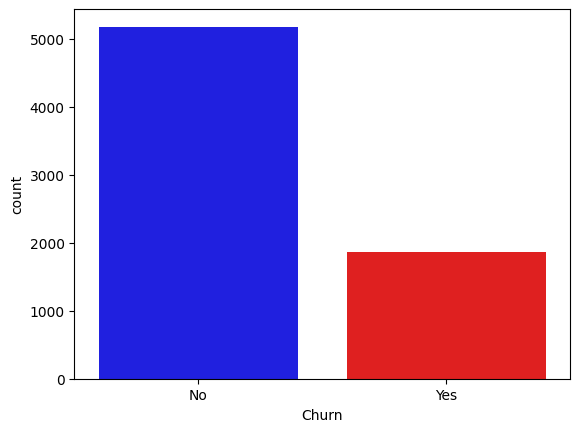

In [ ]:
colors = {'Yes': 'red', 'No': 'blue'}
sns.countplot(x="Churn", data=df, palette=colors)

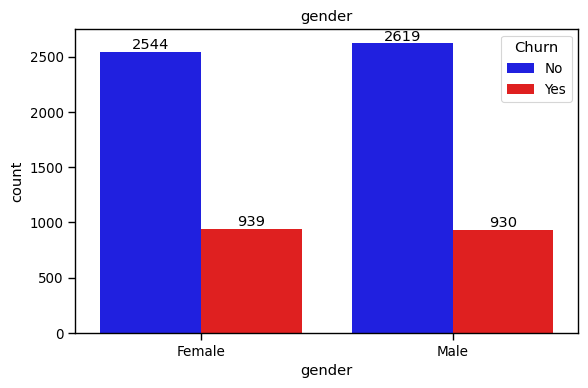

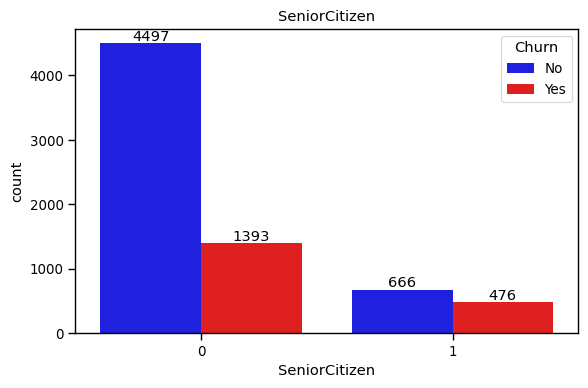

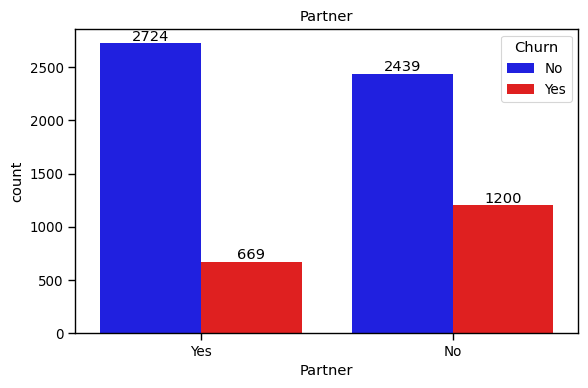

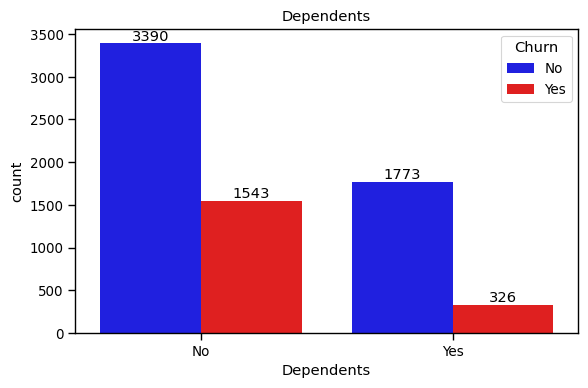

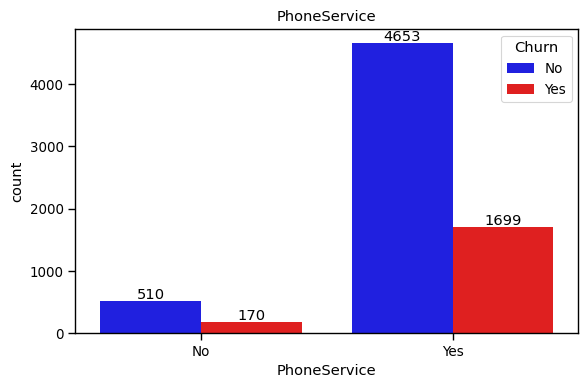

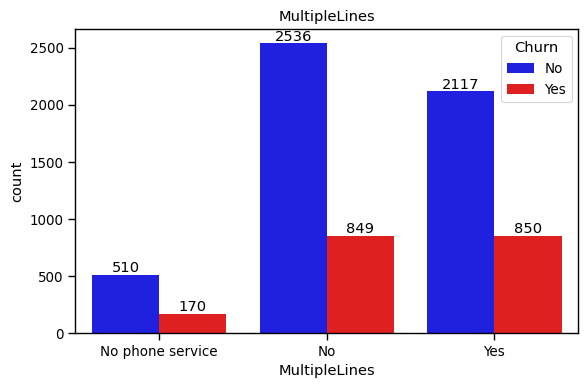

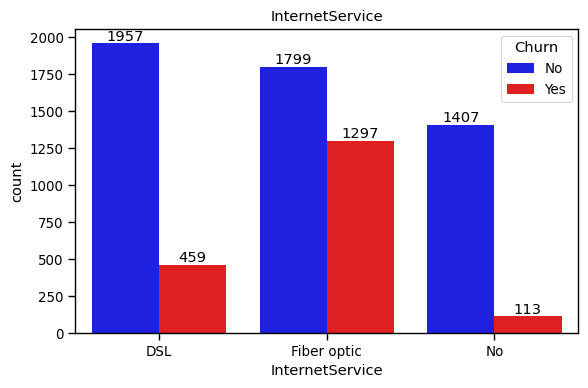

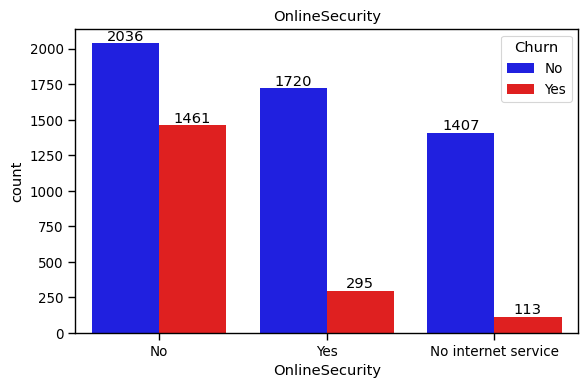

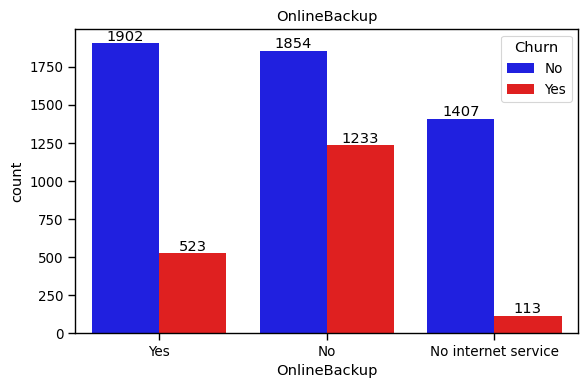

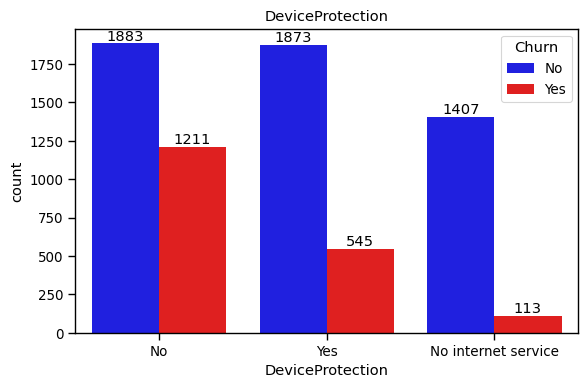

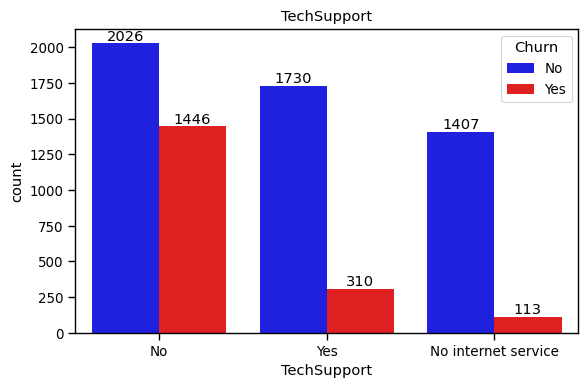

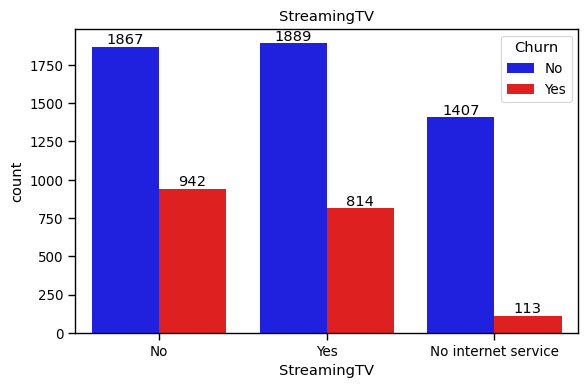

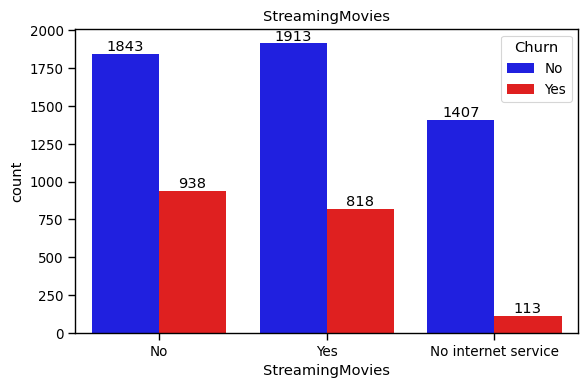

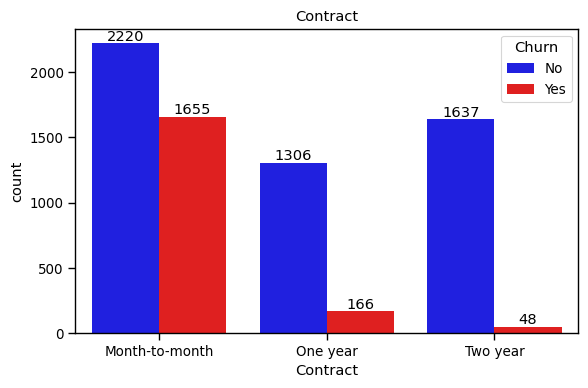

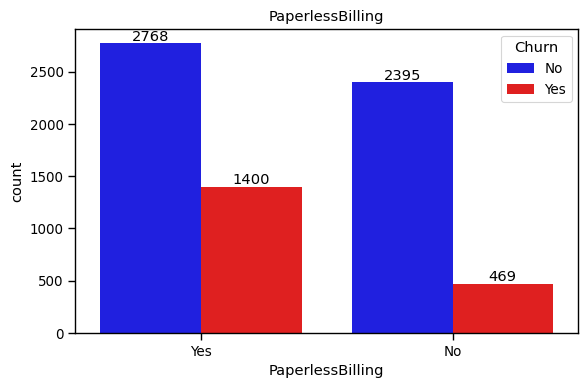

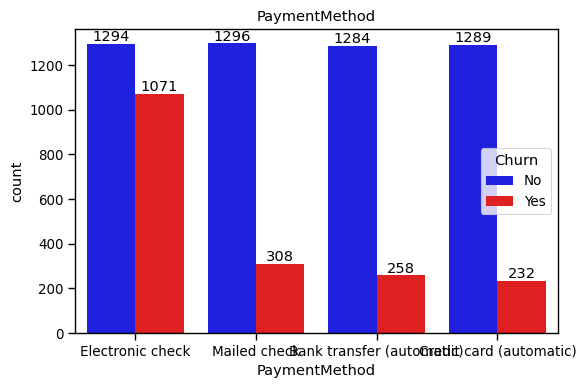

In [ ]:
# colors for Yes and No
colors = {'Yes': 'red', 'No': 'blue'}

for i, predictor in enumerate(df.drop(columns=['Churn', 'TotalCharges', 'MonthlyCharges', 'tenure'])):
    plt.figure(i, figsize=(6, 4))
    ax = sns.countplot(data=df, x=predictor, colors = {'Yes': 'red', 'No': 'blue'})
    plt.title(predictor)
    
    # Add values on top of each bar
    for container in ax.containers:
        ax.bar_label(container)
    
    plt.tight_layout()
    plt.show()


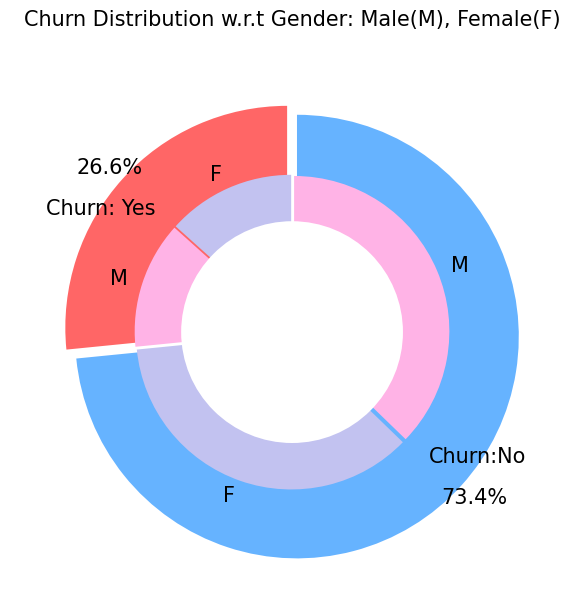

In [ ]:
plt.figure(figsize=(6, 6))
labels =["Churn: Yes","Churn:No"]
values = [1869,5163]
labels_gender = ["F","M","F","M"]
sizes_gender = [939,930 , 2544,2619]
colors = ['#ff6666', '#66b3ff']
colors_gender = ['#c2c2f0','#ffb3e6', '#c2c2f0','#ffb3e6']
explode = (0.3,0.3) 
explode_gender = (0.1,0.1,0.1,0.1)
textprops = {"fontsize":15}
#Plot
plt.pie(values, labels=labels,autopct='%1.1f%%',pctdistance=1.08, labeldistance=0.8,colors=colors, startangle=90,frame=True, explode=explode,radius=10, textprops =textprops, counterclock = True, )
plt.pie(sizes_gender,labels=labels_gender,colors=colors_gender,startangle=90, explode=explode_gender,radius=7, textprops =textprops, counterclock = True, )
#Draw circle
centre_circle = plt.Circle((0,0),5,color='black', fc='white',linewidth=0)
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Churn Distribution w.r.t Gender: Male(M), Female(F)', fontsize=15, y=1.1)

# show plot 
 
plt.axis('equal')
plt.tight_layout()
plt.show()

In [ ]:
fig = px.histogram(df, x="Churn", color="Contract", barmode="group", title="<b>Customer contract distribution<b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

About 75% of customer with Month-to-Month Contract opted to move out as compared to 13% of customrs with One Year Contract and 3% with Two Year Contract

In [ ]:
fig = px.histogram(df, x="Churn", color="PaymentMethod", title="<b>Customer Payment Method distribution w.r.t. Churn</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

In [ ]:
labels = df['PaymentMethod'].unique()
values = df['PaymentMethod'].value_counts()

fig = go.Figure(data=[go.Pie(labels=labels, values=values, hole=.3)])
fig.update_layout(title_text="<b>Payment Method Distribution</b>")
fig.show()


Major customers who moved out were having Electronic Check as Payment Method.
Customers who opted for Credit-Card automatic transfer or Bank Automatic Transfer and Mailed Check as Payment Method were less likely to move out.

In [ ]:
fig = go.Figure()

fig.add_trace(go.Bar(
  x = [['Churn:No', 'Churn:No', 'Churn:Yes', 'Churn:Yes'],
       ["Female", "Male", "Female", "Male"]],
  y = [965, 992, 219, 240],
  name = 'DSL',
))

fig.add_trace(go.Bar(
  x = [['Churn:No', 'Churn:No', 'Churn:Yes', 'Churn:Yes'],
       ["Female", "Male", "Female", "Male"]],
  y = [889, 910, 664, 633],
  name = 'Fiber optic',
))

fig.add_trace(go.Bar(
  x = [['Churn:No', 'Churn:No', 'Churn:Yes', 'Churn:Yes'],
       ["Female", "Male", "Female", "Male"]],
  y = [690, 717, 56, 57],
  name = 'No Internet',
))

fig.update_layout(title_text="<b>Churn Distribution w.r.t. Internet Service and Gender</b>")

fig.show()

A lot of customers choose the Fiber optic service and it's also evident that the customers who use Fiber optic have high churn rate, this might suggest a dissatisfaction with this type of internet service.
Customers having DSL service are majority in number and have less churn rate compared to Fibre optic service.

In [ ]:
color_map = {"Yes": "#FF97FF", "No": "#AB63FA"}
fig = px.histogram(df, x="Churn", color="Dependents", barmode="group", title="<b>Dependents distribution</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

Customers without dependents are more likely to churn

In [ ]:
color_map = {"Yes": '#FFA15A', "No": '#00CC96'}
fig = px.histogram(df, x="Churn", color="Partner", barmode="group", title="<b>Chrun distribution w.r.t. Partners</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

Customers that doesn't have partners are more likely to churn

In [ ]:
color_map = {"Yes": '#00CC96', "No": '#B6E880'}
fig = px.histogram(df, x="Churn", color="SeniorCitizen", title="<b>Chrun distribution w.r.t. Senior Citizen</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

It can be observed that the fraction of senior citizen is very less.
Most of the senior citizens churn.

In [ ]:

color_map = {"Yes": "#FF97FF", "No": "#AB63FA"}
fig = px.histogram(df, x="Churn", color="OnlineSecurity", barmode="group", title="<b>Churn w.r.t Online Security</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

Most customers churn in the absence of online security,

In [ ]:
color_map = {"Yes": '#FFA15A', "No": '#00CC96'}
fig = px.histogram(df, x="Churn", color="PaperlessBilling",  title="<b>Chrun distribution w.r.t. Paperless Billing</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

Customers with Paperless Billing are most likely to churn.

In [ ]:
fig = px.histogram(df, x="Churn", color="TechSupport",barmode="group",  title="<b>Chrun distribution w.r.t. TechSupport</b>")
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

Customers with no TechSupport are most likely to migrate to another service provider.

In [ ]:
color_map = {"Yes": '#00CC96', "No": '#B6E880'}
fig = px.histogram(df, x="Churn", color="PhoneService", title="<b>Chrun distribution w.r.t. Phone Service</b>", color_discrete_map=color_map)
fig.update_layout(width=700, height=500, bargap=0.1)
fig.show()

Very small fraction of customers don't have a phone service and out of that, 1/3rd Customers are more likely to churn.


/var/folders/l4/dry9z8q93w339_gmhcb1wvn40000gn/T/ipykernel_75700/3010334363.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




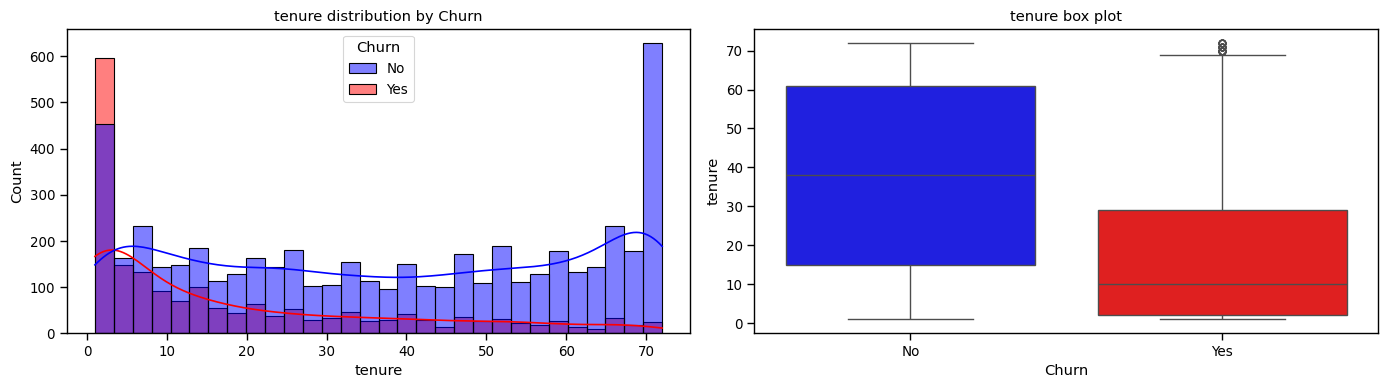

/var/folders/l4/dry9z8q93w339_gmhcb1wvn40000gn/T/ipykernel_75700/3010334363.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




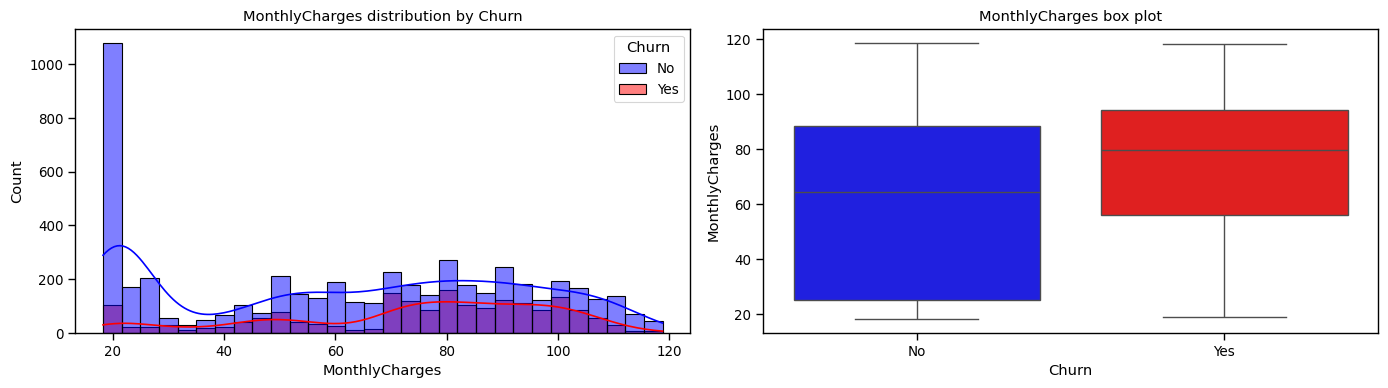

/var/folders/l4/dry9z8q93w339_gmhcb1wvn40000gn/T/ipykernel_75700/3010334363.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




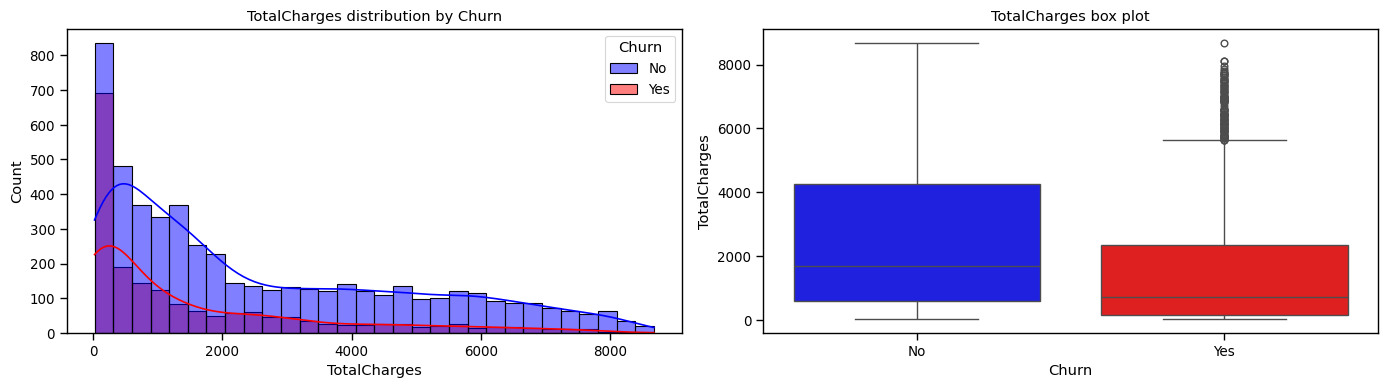

In [ ]:
# ---- Distribution plots for numerical columns ----
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
colors = {'Yes': 'red', 'No': 'blue'}

for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # 1) Histogram + KDE, split by Churn
    sns.histplot(data=df, x=col, hue='Churn', kde=True,
                 palette=colors, bins=30, ax=axes[0])
    axes[0].set_title(f'{col} distribution by Churn')
    
    # 2) Box plot
    sns.boxplot(data=df, x='Churn', y=col, palette=colors, ax=axes[1])
    axes[1].set_title(f'{col} box plot')
    
    plt.tight_layout()
    plt.show()

/var/folders/l4/dry9z8q93w339_gmhcb1wvn40000gn/T/ipykernel_75700/2576396580.py:2: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.


/var/folders/l4/dry9z8q93w339_gmhcb1wvn40000gn/T/ipykernel_75700/2576396580.py:4: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.




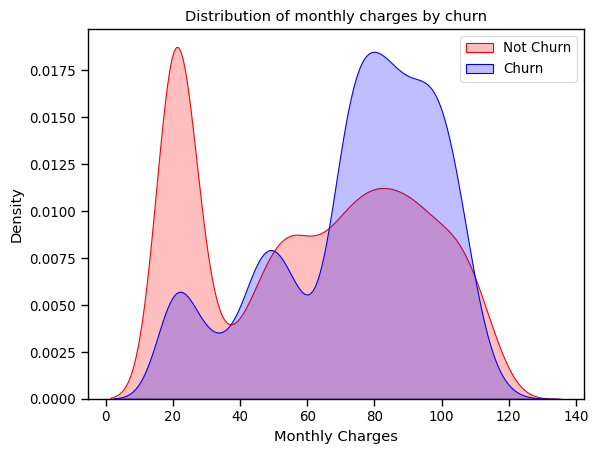

In [ ]:
sns.set_context("paper",font_scale=1.1)
ax = sns.kdeplot(df.MonthlyCharges[(df["Churn"] == 'No') ],
                color="Red", shade = True);
ax = sns.kdeplot(df.MonthlyCharges[(df["Churn"] == 'Yes') ],
                ax =ax, color="Blue", shade= True);
ax.legend(["Not Churn","Churn"],loc='upper right');
ax.set_ylabel('Density');
ax.set_xlabel('Monthly Charges');
ax.set_title('Distribution of monthly charges by churn');

Customers with higher Monthly Charges are also more likely to churn (60,120)

/var/folders/l4/dry9z8q93w339_gmhcb1wvn40000gn/T/ipykernel_75700/2062861112.py:1: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.


/var/folders/l4/dry9z8q93w339_gmhcb1wvn40000gn/T/ipykernel_75700/2062861112.py:3: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.




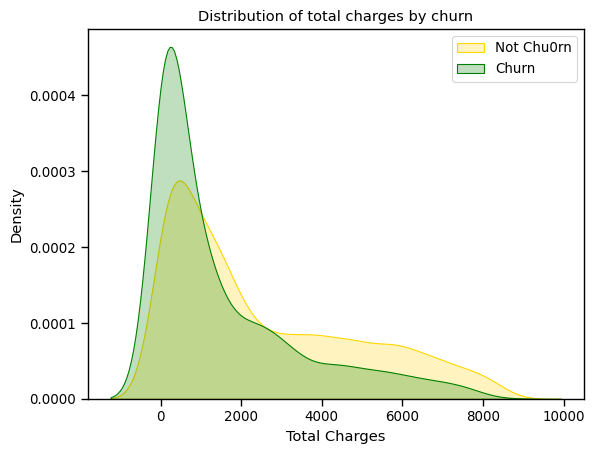

In [ ]:
ax = sns.kdeplot(df.TotalCharges[(df["Churn"] == 'No') ],
                color="Gold", shade = True);
ax = sns.kdeplot(df.TotalCharges[(df["Churn"] == 'Yes') ],
                ax =ax, color="Green", shade= True);
ax.legend(["Not Chu0rn","Churn"],loc='upper right');
ax.set_ylabel('Density');
ax.set_xlabel('Total Charges');
ax.set_title('Distribution of total charges by churn');

In [ ]:
fig = px.box(df, x='Churn', y = 'tenure')

# Update yaxis properties
fig.update_yaxes(title_text='Tenure (Months)', row=1, col=1)
# Update xaxis properties
fig.update_xaxes(title_text='Churn', row=1, col=1)

# Update size and title
fig.update_layout(autosize=True, width=750, height=600,
    title_font=dict(size=25, family='Courier'),
    title='<b>Tenure vs Churn</b>',
)

fig.show()

New customers are more likely to churn

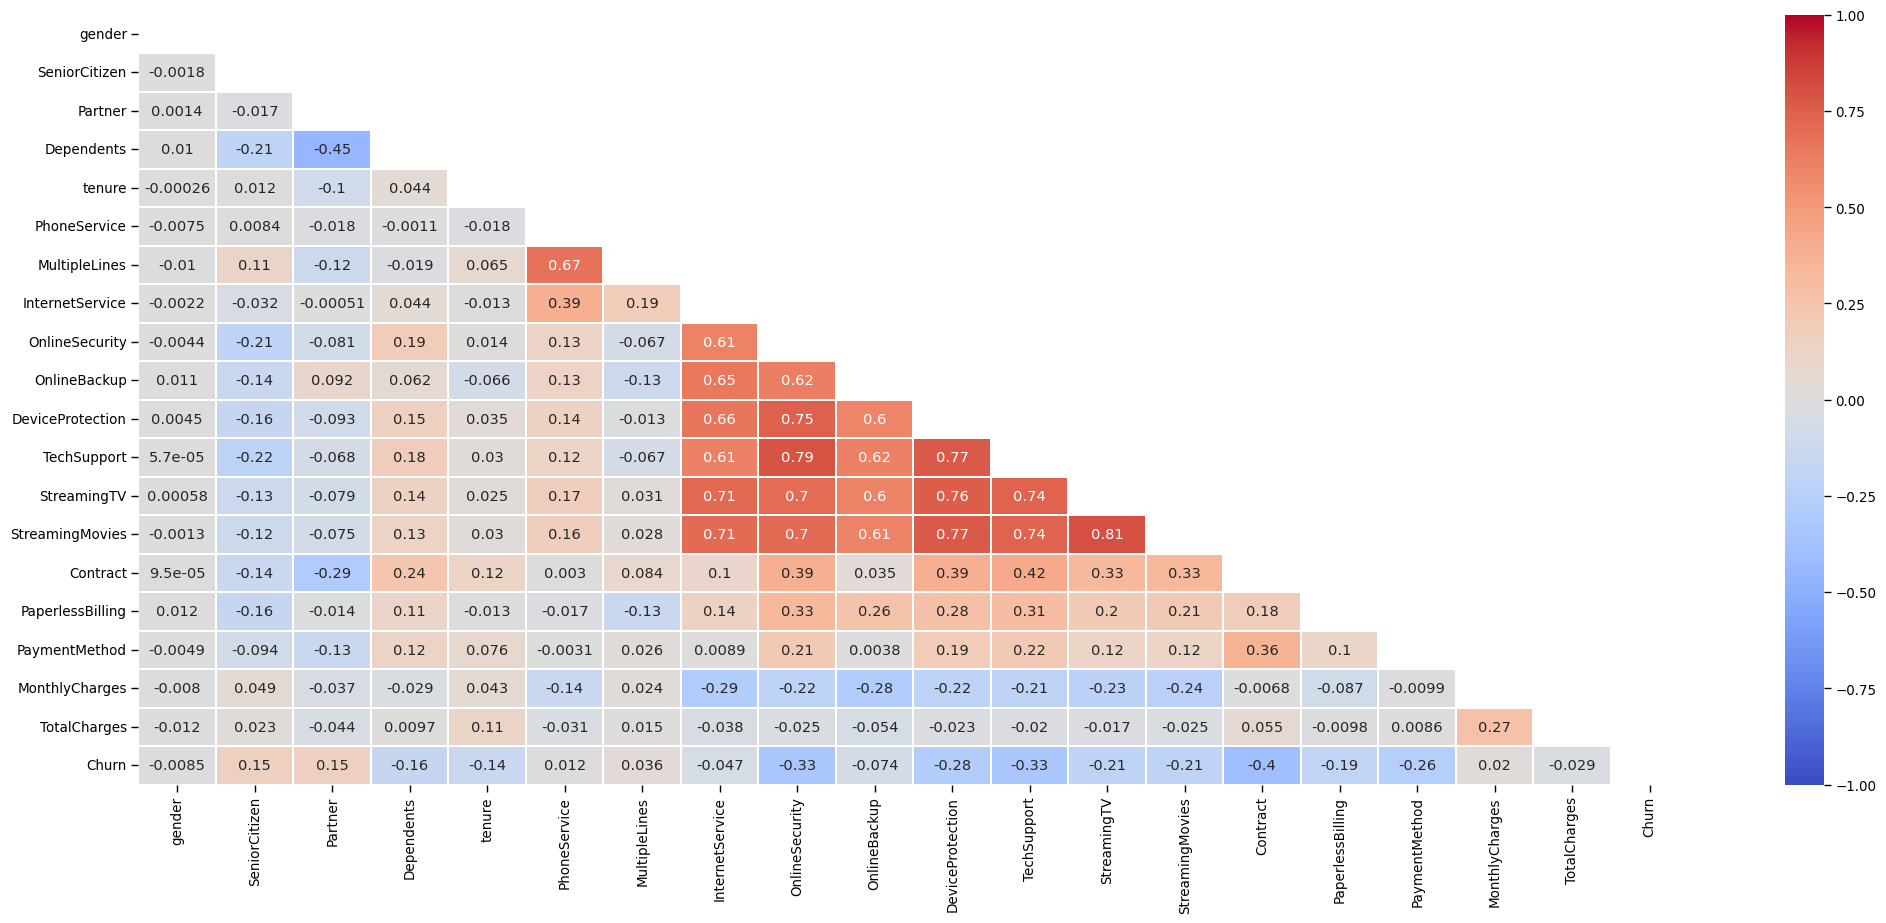

In [ ]:
plt.figure(figsize=(25, 10))

corr = df.apply(lambda x: pd.factorize(x)[0]).corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

ax = sns.heatmap(corr, mask=mask, xticklabels=corr.columns, yticklabels=corr.columns, annot=True, linewidths=.2, cmap='coolwarm', vmin=-1, vmax=1)

#PreProcess

tenure, MonthlyCharges, TotalCharges are numeric.

MonthlyCharges Skewness: -0.22205554798978874


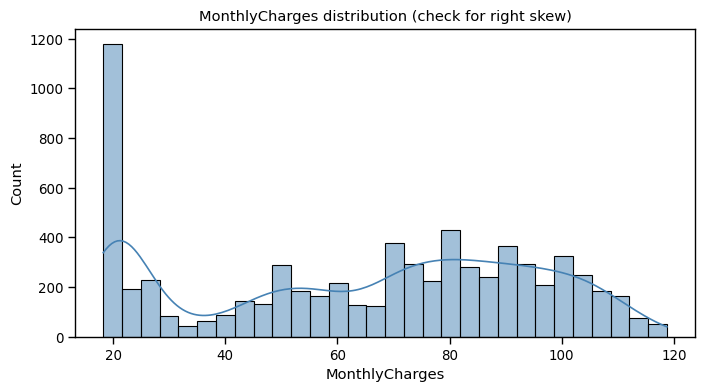

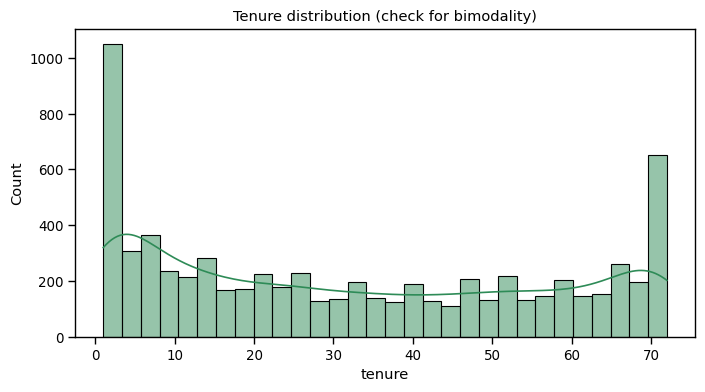


Contract – unique values: 3
Contract
Month-to-month    3875
Two year          1685
One year          1472

InternetService – unique values: 3
InternetService
Fiber optic    3096
DSL            2416
No             1520

PaymentMethod – unique values: 4
PaymentMethod
Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521


In [ ]:
# ── 2. MonthlyCharges – skewness check ────────────────────────────
from scipy.stats import skew
print("MonthlyCharges Skewness:", skew(df['MonthlyCharges']))

plt.figure(figsize=(8,4))
sns.histplot(df['MonthlyCharges'], bins=30, kde=True, color='steelblue')
plt.title('MonthlyCharges distribution (check for right skew)')
plt.show()

# ── 3. Tenure – bimodality check ──────────────────────────────────
plt.figure(figsize=(8,4))
sns.histplot(df['tenure'], bins=30, kde=True, color='seagreen')
plt.title('Tenure distribution (check for bimodality)')
plt.show()

# ── 4. Categorical cardinality ────────────────────────────────────
for col in ['Contract', 'InternetService', 'PaymentMethod']:
    print(f"\n{'='*40}\n{col} – unique values: {df[col].nunique()}")
    print(df[col].value_counts().to_string())

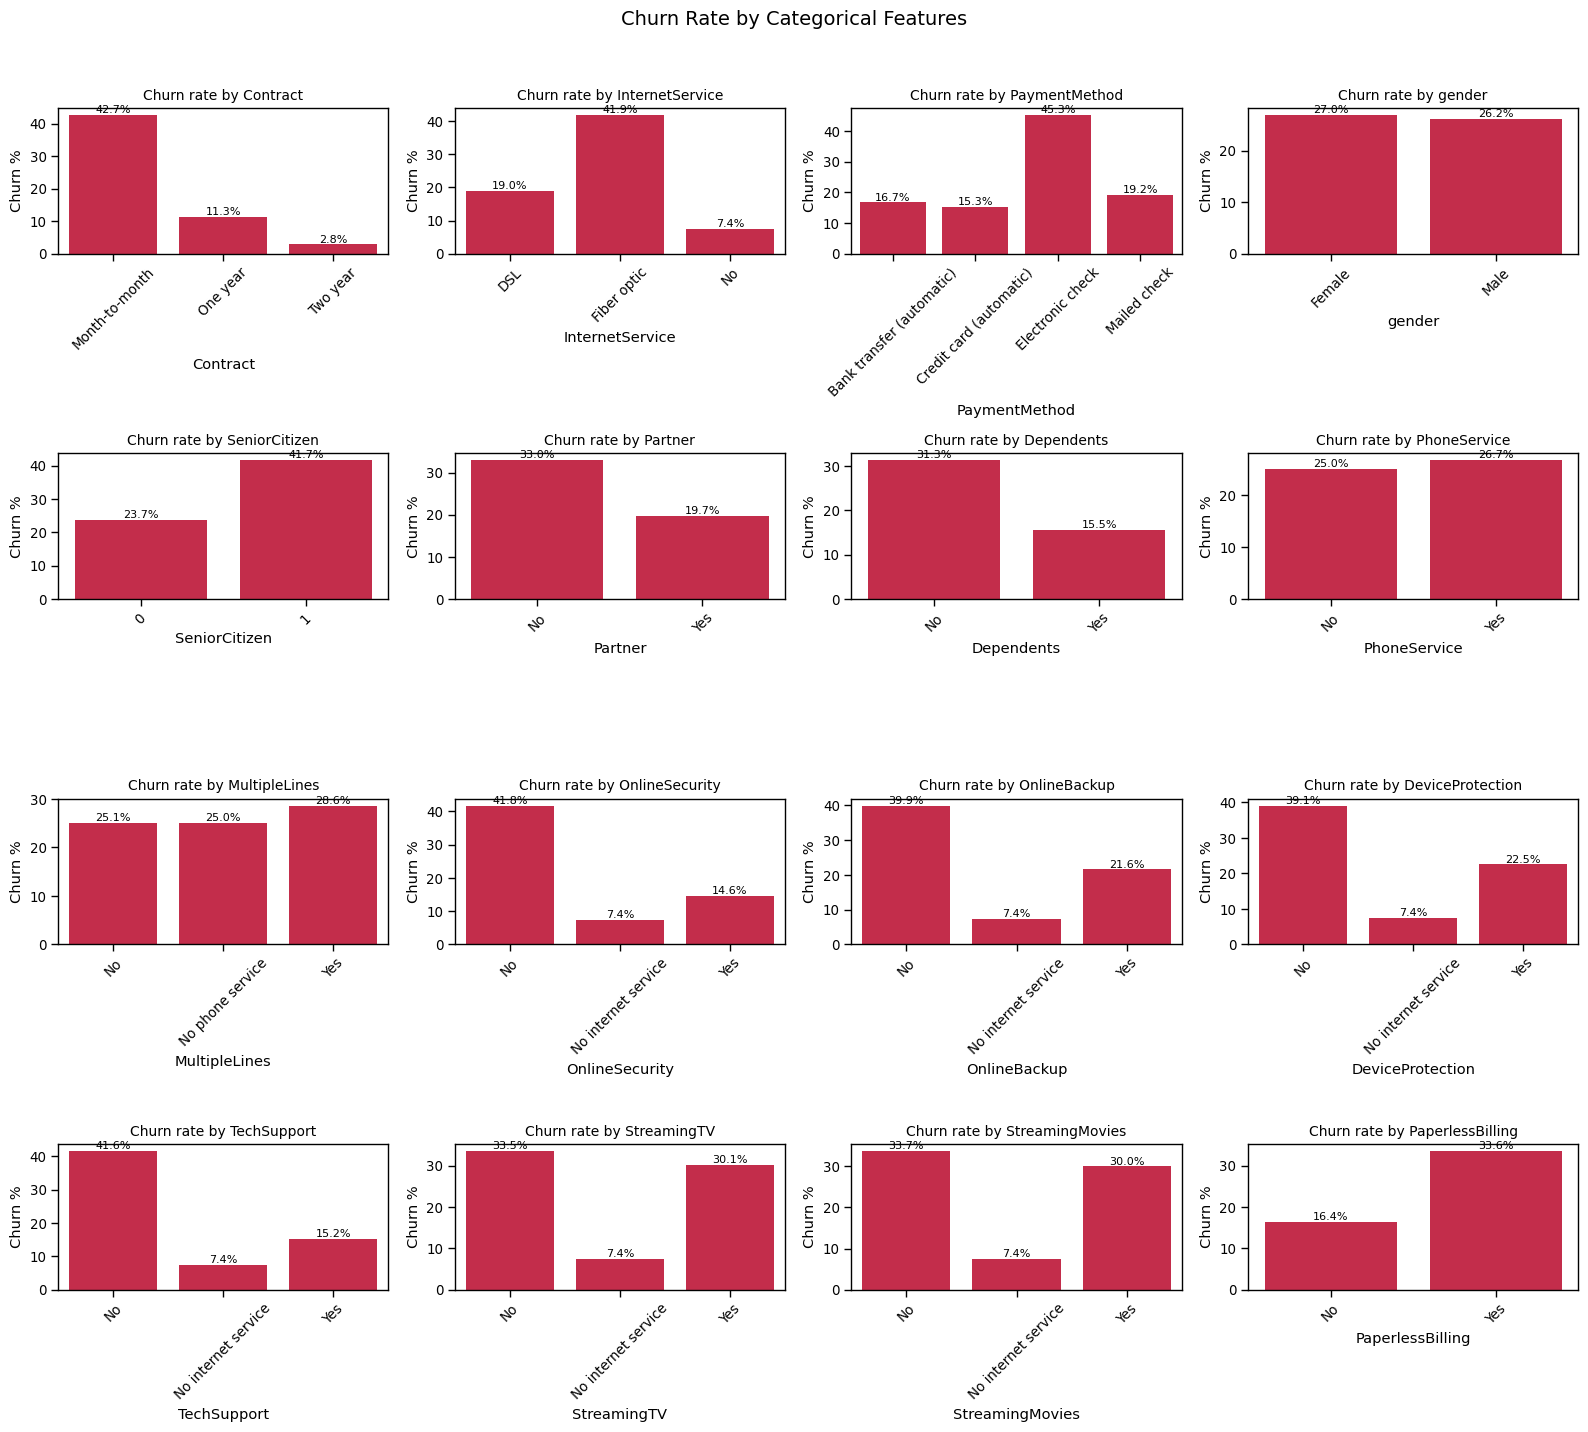

/var/folders/l4/dry9z8q93w339_gmhcb1wvn40000gn/T/ipykernel_75700/2807538358.py:35: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




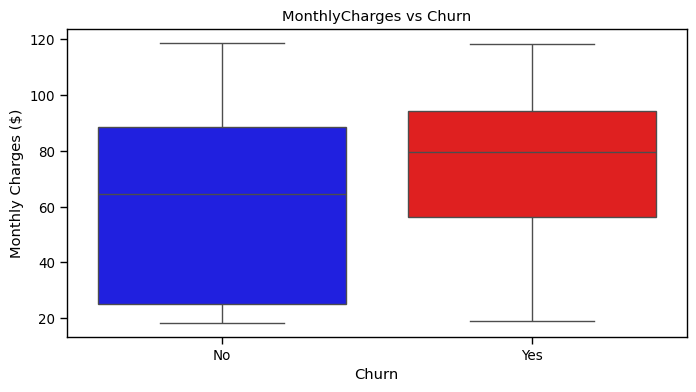

/var/folders/l4/dry9z8q93w339_gmhcb1wvn40000gn/T/ipykernel_75700/2807538358.py:42: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/var/folders/l4/dry9z8q93w339_gmhcb1wvn40000gn/T/ipykernel_75700/2807538358.py:44: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




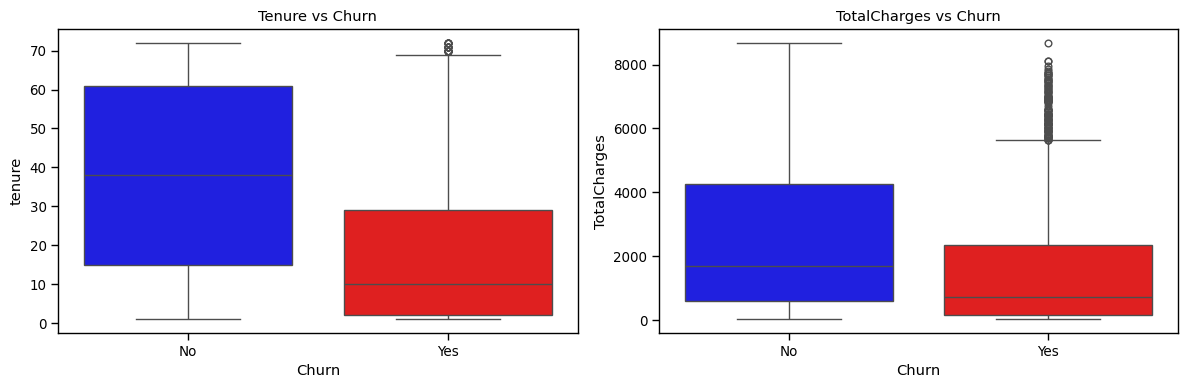

In [ ]:
# ── Bivariate analysis ─────────────────────────────────────────────

# 1. Churn rate by categorical predictors
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'gender', 'SeniorCitizen', 
            'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
            'PaperlessBilling']

fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.ravel()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].value_counts(normalize=True).mul(100).rename('percent').reset_index()
    churn_rate = churn_rate[churn_rate['Churn'] == 'Yes']  # keep only churn=Yes percentages
    
    sns.barplot(data=churn_rate, x=col, y='percent', ax=axes[i], color='crimson')
    axes[i].set_title(f'Churn rate by {col}', fontsize=10)
    axes[i].set_ylabel('Churn %')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Add value labels
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.1f%%', fontsize=8)

# Hide unused subplots (if any)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Churn Rate by Categorical Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 2. Boxplots – MonthlyCharges vs Churn
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette={'Yes': 'red', 'No': 'blue'})
plt.title('MonthlyCharges vs Churn')
plt.ylabel('Monthly Charges ($)')
plt.show()

# Optional – also boxplots for tenure and TotalCharges
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x='Churn', y='tenure', palette={'Yes': 'red', 'No': 'blue'}, ax=axes[0])
axes[0].set_title('Tenure vs Churn')
sns.boxplot(data=df, x='Churn', y='TotalCharges', palette={'Yes': 'red', 'No': 'blue'}, ax=axes[1])
axes[1].set_title('TotalCharges vs Churn')
plt.tight_layout()
plt.show()

In [ ]:
# همبستگی ویژگی‌های عددی با Churn (با تبدیل Churn به 0/1)
df['Churn_numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})
numeric_corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_numeric']].corr(method='pearson')['Churn_numeric'].sort_values(ascending=False)
print("Numeric Correlations with Churn:")
print(numeric_corr)


Numeric Correlations with Churn:
Churn_numeric     1.000000
MonthlyCharges    0.192858
SeniorCitizen     0.150541
TotalCharges     -0.199484
tenure           -0.354049
Name: Churn_numeric, dtype: float64


statistics shit

غیر خطی 

In [ ]:
# همبستگی ویژگی‌های عددی با Churn (با تبدیل Churn به 0/1)
df['Churn_numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})
numeric_corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_numeric']].corr(method='spearman')['Churn_numeric'].sort_values(ascending=False)
print("Numeric Correlations with Churn:")
print(numeric_corr)


Numeric Correlations with Churn:
Churn_numeric     1.000000
MonthlyCharges    0.184167
SeniorCitizen     0.150541
TotalCharges     -0.232190
tenure           -0.369659
Name: Churn_numeric, dtype: float64


In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

# لیست ویژگی‌های دسته‌ای
categorical_features = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]

# تابع برای محاسبه Chi-Square و p-value
def chi_square_test(feature, target='Churn'):
    contingency_table = pd.crosstab(df[feature], df[target])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    return chi2, p_value

# محاسبه و چاپ نتایج
print("همبستگی Chi-Square بین ویژگی‌های دسته‌ای و Churn:")
for feature in categorical_features:
    chi2, p_value = chi_square_test(feature)
    print(f"{feature}: Chi2 = {chi2:.3f}, p-value = {p_value:.5f}")
    if p_value < 0.05:
        print(f"  → رابطه معناداری بین {feature} و Churn وجود دارد.")
    else:
        print(f"  → رابطه معناداری بین {feature} و Churn وجود ندارد.")
    print("---")

همبستگی Chi-Square بین ویژگی‌های دسته‌ای و Churn:
gender: Chi2 = 0.475, p-value = 0.49049
  → رابطه معناداری بین gender و Churn وجود ندارد.
---
Partner: Chi2 = 157.503, p-value = 0.00000
  → رابطه معناداری بین Partner و Churn وجود دارد.
---
Dependents: Chi2 = 186.322, p-value = 0.00000
  → رابطه معناداری بین Dependents و Churn وجود دارد.
---
PhoneService: Chi2 = 0.874, p-value = 0.34992
  → رابطه معناداری بین PhoneService و Churn وجود ندارد.
---
MultipleLines: Chi2 = 11.272, p-value = 0.00357
  → رابطه معناداری بین MultipleLines و Churn وجود دارد.
---
InternetService: Chi2 = 728.696, p-value = 0.00000
  → رابطه معناداری بین InternetService و Churn وجود دارد.
---
OnlineSecurity: Chi2 = 846.677, p-value = 0.00000
  → رابطه معناداری بین OnlineSecurity و Churn وجود دارد.
---
OnlineBackup: Chi2 = 599.175, p-value = 0.00000
  → رابطه معناداری بین OnlineBackup و Churn وجود دارد.
---
DeviceProtection: Chi2 = 555.880, p-value = 0.00000
  → رابطه معناداری بین DeviceProtection و Churn وجود دارد.


In [ ]:
from scipy.stats import f_oneway

# لیست ویژگی‌های دسته‌ای که می‌خوایم با یک متغیر عددی مقایسه کنیم
# مثال: آیا میانگین MonthlyCharges بین گروه‌های مختلف یک ویژگی دسته‌ای تفاوت معناداری دارد؟
numeric_target = 'MonthlyCharges'  # می‌تونی این رو به TotalCharges یا tenure هم تغییر بدی

print(f"همبستگی ANOVA بین ویژگی‌های دسته‌ای و {numeric_target}:")
for feature in categorical_features:
    groups = [df[df[feature] == category][numeric_target] for category in df[feature].unique()]
    f_stat, p_value = f_oneway(*groups)
    print(f"{feature}: F-statistic = {f_stat:.3f}, p-value = {p_value:.5f}")
    if p_value < 0.05:
        print(f"  → تفاوت معناداری بین گروه‌های {feature} در {numeric_target} وجود دارد.")
    else:
        print(f"  → تفاوت معناداری بین گروه‌های {feature} در {numeric_target} وجود ندارد.")
    print("---")

همبستگی ANOVA بین ویژگی‌های دسته‌ای و MonthlyCharges:
gender: F-statistic = 1.335, p-value = 0.24795
  → تفاوت معناداری بین گروه‌های gender در MonthlyCharges وجود ندارد.
---
Partner: F-statistic = 67.925, p-value = 0.00000
  → تفاوت معناداری بین گروه‌های Partner در MonthlyCharges وجود دارد.
---
Dependents: F-statistic = 89.859, p-value = 0.00000
  → تفاوت معناداری بین گروه‌های Dependents در MonthlyCharges وجود دارد.
---
PhoneService: F-statistic = 460.839, p-value = 0.00000
  → تفاوت معناداری بین گروه‌های PhoneService در MonthlyCharges وجود دارد.
---
MultipleLines: F-statistic = 1198.610, p-value = 0.00000
  → تفاوت معناداری بین گروه‌های MultipleLines در MonthlyCharges وجود دارد.
---
InternetService: F-statistic = 16065.032, p-value = 0.00000
  → تفاوت معناداری بین گروه‌های InternetService در MonthlyCharges وجود دارد.
---
OnlineSecurity: F-statistic = 4943.734, p-value = 0.00000
  → تفاوت معناداری بین گروه‌های OnlineSecurity در MonthlyCharges وجود دارد.
---
OnlineBackup: F-statistic = 

missing

TotalCharges: این ستون ممکن است برای مشتریانی که تازه وارد شده‌اند (tenure کم) مقدار کم یا صفر داشته باشد

In [ ]:
print((df["TotalCharges"] == " ").sum())# 2. تبدیل مقادیر خالی به NaN
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

0


In [ ]:
df = df.dropna(subset=["TotalCharges"])
print("تعداد رکوردها بعد از dropna:", len(df))

تعداد رکوردها بعد از dropna: 7032


outliers

/var/folders/l4/dry9z8q93w339_gmhcb1wvn40000gn/T/ipykernel_75700/2157125760.py:31: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/var/folders/l4/dry9z8q93w339_gmhcb1wvn40000gn/T/ipykernel_75700/2157125760.py:31: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.





Column: tenure
  Range        : [1.00 – 72.00]
  IQR bounds   : [-60.00, 124.00]
  Outliers     : 0 / 7032 (0.00%)
  → Clean column, no outliers detected.

Column: MonthlyCharges
  Range        : [18.25 – 118.75]
  IQR bounds   : [-45.82, 171.27]
  Outliers     : 0 / 7032 (0.00%)
  → Clean column, no outliers detected.

Column: TotalCharges
  Range        : [18.80 – 8684.80]
  IQR bounds   : [-4688.48, 8884.67]
  Outliers     : 0 / 7032 (0.00%)
  → Clean column, no outliers detected.


/var/folders/l4/dry9z8q93w339_gmhcb1wvn40000gn/T/ipykernel_75700/2157125760.py:31: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




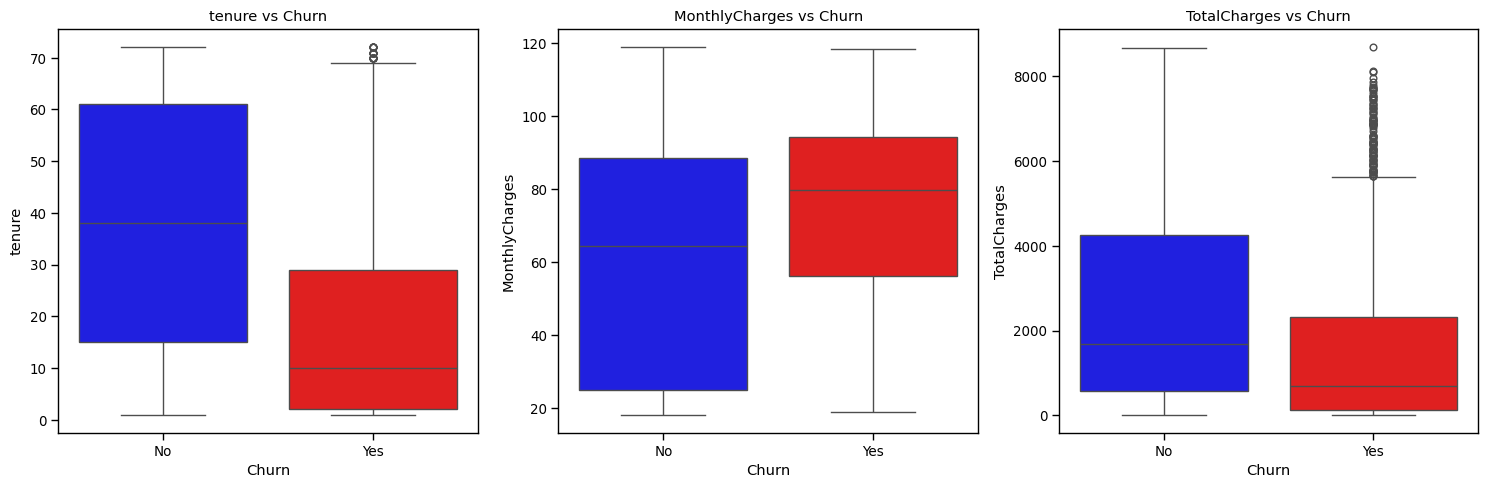

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)     # now it actually removes rows with missing charges
# ── Outlier Detection (IQR Method) ─────────────────────────────────

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(num_cols):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\n{'='*50}")
    print(f"Column: {col}")
    print(f"  Range        : [{df[col].min():.2f} – {df[col].max():.2f}]")
    print(f"  IQR bounds   : [{lower:.2f}, {upper:.2f}]")
    print(f"  Outliers     : {len(outliers)} / {len(df)} ({len(outliers)/len(df)*100:.2f}%)")
    if len(outliers) > 0:
        print(f"  Max outlier  : {outliers[col].max():.2f}")
        print(f"  Sample rows  :")
        print(outliers[['tenure','MonthlyCharges','TotalCharges','Churn']].head(5))
    else:
        print(f"  → Clean column, no outliers detected.")

    # Boxplot split by Churn
    sns.boxplot(data=df, x='Churn', y=col,
                palette={'Yes':'red','No':'blue'}
                , ax=axes[i]
                )
    axes[i].set_title(f'{col} vs Churn')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

In [ ]:
df.head(1)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_numeric
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0


encoding

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Label Encoding برای ستون‌های باینری
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# One-Hot Encoding برای ستون‌های چنددسته‌ای
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
              'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

# ذخیره فایل جدید
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
df = df.drop(columns=['Churn_numeric'])

In [ ]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  MultipleLines_No phone service         7032 non-null   int64  
 11  MultipleL

feature Engeinering 

In [ ]:
# # 5. Optional: گروه‌بندی tenure (اگر بخواهید)
# # معمولاً خود tenure را به‌صورت عددی نگه می‌داریم، اما اگر بخواهید گروه‌بندی کنید:
# bins = [0, 12, 24, 36, 48, 60, 72]  # مثال: سال‌های ۱ تا ۶
# labels = ["0-1y", "1-2y", "2-3y", "3-4y", "4-5y", "5-6y"]
# df_encoded["tenure_group"] = pd.cut(df_encoded["tenure"], bins=bins, labels=labels, right=False)

# print("گروه‌بندی tenure (اختیاری) انجام شد.")

# # 6. نمایش ستون‌های جدید
# print("\nستون‌های جدید (نمونه):")
# print(df_encoded.columns.tolist()[-20:])  # ۲۰ ستون آخر برای نمونه

Feature engineering:
Tenure buckets: Create tenure_group (0-12, 12-24, ...) if non-linear relationships suspected.
Service count: Num_Services = sum of OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies (each Yes=1).
Charge ratios: MonthlyCharges_per_Tenure = MonthlyCharges / (tenure + 1).
Drop irrelevant: customerID (no predictive power).

بیشتر کار تا اینجا بسری بوده ، ولی اگر بخواهی از 
statistic shit  
استفاده کنی به لیکیج میخوری